# Analiza performanței modelelor de clasificare în funcție de complexitatea datelor

**Studiu experimental — partea practică a lucrării de disertație**

Acest notebook implementează experimentele descrise în capitolul de metodologie:

- **Scenariul A** — variația dimensionalității (`n_features`)
- **Scenariul B** — variația zgomotului în etichete (`flip_y`)
- **Scenariul C** — variația redundanței (`n_redundant`)

Modele studiate: **Regresie Logistică, KNN, SVM (RBF), Random Forest, Rețea Neuronală (MLP)**.

Metrici raportate: acuratețe, F1, AUC-ROC, timp de antrenare și deviația standard pe validarea încrucișată (5-fold).

Toate experimentele sunt repetate de mai multe ori cu seed-uri diferite, iar rezultatele sunt salvate în fișiere CSV pentru utilizare ulterioară în lucrare.


## 1. Setup și importuri

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
from pathlib import Path

from sklearn.datasets import make_classification
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 2. Configurare globală

Parametrii globali pentru toate experimentele.

In [2]:
# Reproducibilitate
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Configurare experimente
N_SAMPLES = 1000      # numarul de instante per dataset
N_REPEATS = 5         # cate dataset-uri diferite generam pentru fiecare valoare a parametrului
CV_FOLDS = 5          # numarul de partitii pentru cross-validation

# Director pentru salvarea rezultatelor
RESULTS_DIR = Path("rezultate")
RESULTS_DIR.mkdir(exist_ok=True)
print(f"Rezultatele vor fi salvate in: {RESULTS_DIR.absolute()}")


Rezultatele vor fi salvate in: d:\disertatie_practica\rezultate


## 3. Definirea modelelor

Pentru fiecare model este construit un `Pipeline` care include scalarea atributelor (`StandardScaler`) acolo unde scalarea este relevantă (modele bazate pe distanță, modele liniare, rețele neuronale). Random Forest nu necesită scalare.


In [3]:
def get_models(random_state=42):
    """Returneaza un dictionar cu cele 5 modele de clasificare configurate."""
    return {
        "Regresie Logistica": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000, random_state=random_state)),
        ]),
        "KNN": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", KNeighborsClassifier(n_neighbors=5, weights="uniform")),
        ]),
        "SVM (RBF)": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(kernel="rbf", gamma="scale", C=1.0,
                        probability=False, random_state=random_state)),
        ]),
        "Random Forest": RandomForestClassifier(
            n_estimators=100, criterion="gini",
            random_state=random_state, n_jobs=-1
        ),
        "Retea Neuronala (MLP)": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(hidden_layer_sizes=(64,), activation="relu",
                                  solver="adam", max_iter=500,
                                  random_state=random_state)),
        ]),
    }

# Test rapid: lista modelelor
list(get_models().keys())


['Regresie Logistica',
 'KNN',
 'SVM (RBF)',
 'Random Forest',
 'Retea Neuronala (MLP)']

## 4. Funcția de evaluare

Pentru fiecare model se calculează, prin **5-fold stratified cross-validation**:

- acuratețea medie și deviația standard
- scorul F1 mediu și deviația standard
- AUC-ROC mediu și deviația standard
- timpul total de antrenare-evaluare

`cross_validate` calculează toate cele trei metrici într-o singură rulare a CV, economisind timp față de apelarea repetată a lui `cross_val_score`.


In [4]:
def evaluate_models(X, y, models, cv_folds=CV_FOLDS, cv_seed=42):
    """Antreneaza fiecare model cu k-fold CV si returneaza un dict de metrici."""
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=cv_seed)
    scoring = ["accuracy", "f1", "roc_auc"]
    out = {}
    for name, model in models.items():
        t0 = time.time()
        scores = cross_validate(
            model, X, y, cv=cv, scoring=scoring,
            n_jobs=-1, return_train_score=False
        )
        elapsed = time.time() - t0
        out[name] = {
            "accuracy_mean": scores["test_accuracy"].mean(),
            "accuracy_std":  scores["test_accuracy"].std(),
            "f1_mean":       scores["test_f1"].mean(),
            "f1_std":        scores["test_f1"].std(),
            "auc_mean":      scores["test_roc_auc"].mean(),
            "auc_std":       scores["test_roc_auc"].std(),
            "train_time":    elapsed,
        }
    return out


In [5]:
def run_scenario(param_name, param_values, dataset_builder, n_repeats=N_REPEATS, verbose=True):
    """
    Ruleaza un scenariu experimental.

    Parametri
    ---------
    param_name : str
        Numele parametrului variat (ex: 'n_features', 'flip_y', 'n_redundant').
    param_values : iterable
        Valorile pe care le va lua parametrul.
    dataset_builder : callable
        Functie care primeste (param_value, seed) si returneaza (X, y).
    n_repeats : int
        Cate repetitii cu seed-uri diferite per valoare de parametru.
    """
    rows = []
    total = len(param_values) * n_repeats
    step = 0
    for pv in param_values:
        for rep in range(n_repeats):
            step += 1
            seed = rep * 100 + 7
            X, y = dataset_builder(pv, seed)
            models = get_models(random_state=seed)
            results = evaluate_models(X, y, models, cv_seed=seed)
            for model_name, metrics in results.items():
                row = {param_name: pv, "repetitie": rep, "model": model_name}
                row.update(metrics)
                rows.append(row)
            if verbose:
                print(f"  [{step:>3}/{total}] {param_name}={pv}, rep={rep} — done")
    return pd.DataFrame(rows)


## 5. Scenariul A — Impactul dimensionalității

Se variază `n_features` pe intervalul `[5, 10, 20, 50, 100, 200, 500]`, păstrând:

- `n_samples = 1000`
- proporția atributelor informative la 50% (`n_informative = n_features // 2`)
- `n_redundant = 0` și `flip_y = 0.01` (zgomot minim)

Pentru fiecare valoare se generează `N_REPEATS` seturi independente cu seed-uri distincte, pentru a obține medii și deviații standard robuste.


In [6]:
N_FEATURES_LIST = [5, 10, 20, 50, 100, 200, 500]

def build_dataset_A(n_features, seed):
    n_informative = max(2, n_features // 2)
    X, y = make_classification(
        n_samples=N_SAMPLES,
        n_features=n_features,
        n_informative=n_informative,
        n_redundant=0,
        n_repeated=0,
        n_classes=2,
        flip_y=0.01,
        class_sep=1.0,
        random_state=seed,
    )
    return X, y

print("Pornesc Scenariul A — dimensionalitate...")
df_A = run_scenario("n_features", N_FEATURES_LIST, build_dataset_A)
df_A.to_csv(RESULTS_DIR / "scenariu_A_dimensionalitate.csv", index=False)
print("Salvat: scenariu_A_dimensionalitate.csv")
df_A.head()


Pornesc Scenariul A — dimensionalitate...
  [  1/35] n_features=5, rep=0 — done
  [  2/35] n_features=5, rep=1 — done
  [  3/35] n_features=5, rep=2 — done
  [  4/35] n_features=5, rep=3 — done
  [  5/35] n_features=5, rep=4 — done
  [  6/35] n_features=10, rep=0 — done
  [  7/35] n_features=10, rep=1 — done
  [  8/35] n_features=10, rep=2 — done
  [  9/35] n_features=10, rep=3 — done
  [ 10/35] n_features=10, rep=4 — done
  [ 11/35] n_features=20, rep=0 — done
  [ 12/35] n_features=20, rep=1 — done
  [ 13/35] n_features=20, rep=2 — done
  [ 14/35] n_features=20, rep=3 — done
  [ 15/35] n_features=20, rep=4 — done
  [ 16/35] n_features=50, rep=0 — done
  [ 17/35] n_features=50, rep=1 — done
  [ 18/35] n_features=50, rep=2 — done
  [ 19/35] n_features=50, rep=3 — done
  [ 20/35] n_features=50, rep=4 — done
  [ 21/35] n_features=100, rep=0 — done
  [ 22/35] n_features=100, rep=1 — done
  [ 23/35] n_features=100, rep=2 — done
  [ 24/35] n_features=100, rep=3 — done
  [ 25/35] n_features=1

,n_features,repetitie,model,accuracy_mean,accuracy_std,f1_mean,f1_std,auc_mean,auc_std,train_time
0,5,0,Regresie Logistica,0.937,0.019131,0.935124,0.020112,0.969098,0.008806,4.511140
1,5,0,KNN,0.926,0.020833,0.923715,0.021791,0.957187,0.019682,3.567900
2,5,0,SVM (RBF),0.944,0.018276,0.941604,0.019847,0.969778,0.010051,3.440461
3,5,0,Random Forest,0.950,0.014832,0.948870,0.015507,0.966978,0.009557,3.763783
4,5,0,Retea Neuronala (MLP),0.941,0.020833,0.939225,0.022153,0.971858,0.008351,1.476372


### 5.1. Sinteză tabelară — Scenariul A

In [7]:
summary_A = (
    df_A.groupby(["n_features", "model"])
        .agg(accuracy_mean=("accuracy_mean", "mean"),
             accuracy_std=("accuracy_mean", "std"),
             f1_mean=("f1_mean", "mean"),
             auc_mean=("auc_mean", "mean"),
             train_time=("train_time", "mean"))
        .round(4)
        .reset_index()
)
summary_A.to_csv(RESULTS_DIR / "scenariu_A_sumar.csv", index=False)
summary_A


,n_features,model,accuracy_mean,accuracy_std,f1_mean,auc_mean,train_time
0,5,KNN,0.9026,0.0321,0.9021,0.9510,0.7538
1,5,Random Forest,0.9292,0.0347,0.9293,0.9678,1.2067
2,5,Regresie Logistica,0.9090,0.0478,0.9092,0.9561,0.9328
3,5,Retea Neuronala (MLP),0.9324,0.0223,0.9324,0.9753,1.3815
4,5,SVM (RBF),0.9186,0.0333,0.9194,0.9618,0.7502
5,10,KNN,0.8692,0.0464,0.8702,0.9333,0.0481
6,10,Random Forest,0.8998,0.0267,0.8996,0.9631,0.4737
7,10,Regresie Logistica,0.8250,0.0731,0.8256,0.8939,0.0384
8,10,Retea Neuronala (MLP),0.9204,0.0297,0.9204,0.9716,1.4602
9,10,SVM (RBF),0.9002,0.0478,0.9012,0.9586,0.0966


### 5.2. Grafice — Scenariul A

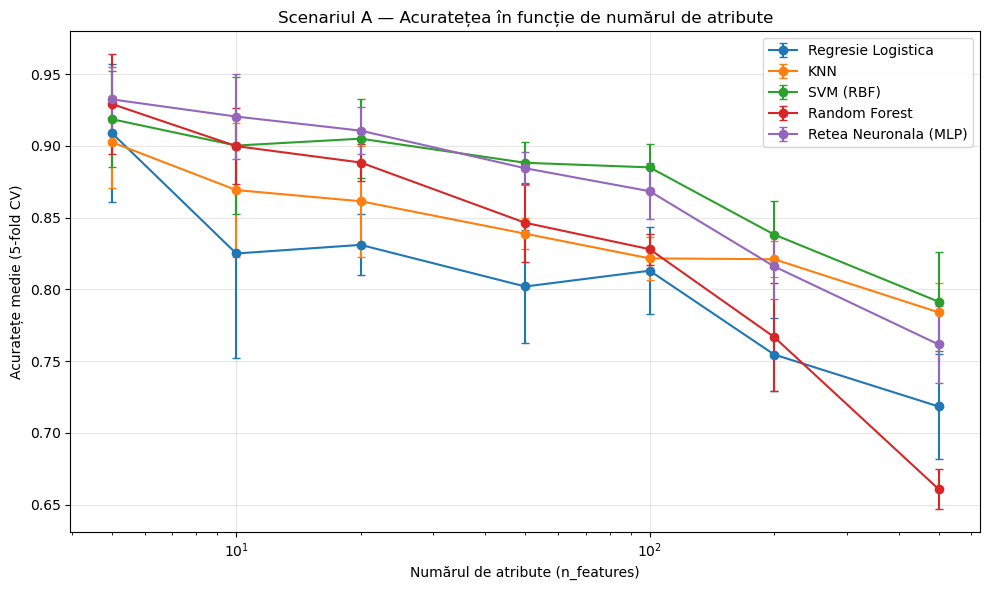

In [8]:
def plot_scenario(df, x_col, y_col, title, xlabel, ylabel, logx=False, savepath=None):
    fig, ax = plt.subplots(figsize=(10, 6))
    for model in df["model"].unique():
        sub = (df[df["model"] == model]
               .groupby(x_col)[y_col]
               .agg(["mean", "std"])
               .reset_index())
        ax.errorbar(sub[x_col], sub["mean"], yerr=sub["std"],
                    marker="o", capsize=3, label=model)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if logx:
        ax.set_xscale("log")
    ax.legend(loc="best")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=150, bbox_inches="tight")
    plt.show()

plot_scenario(df_A, "n_features", "accuracy_mean",
              title="Scenariul A — Acuratețea în funcție de numărul de atribute",
              xlabel="Numărul de atribute (n_features)",
              ylabel="Acuratețe medie (5-fold CV)",
              logx=True,
              savepath=RESULTS_DIR / "scenariu_A_accuracy.png")


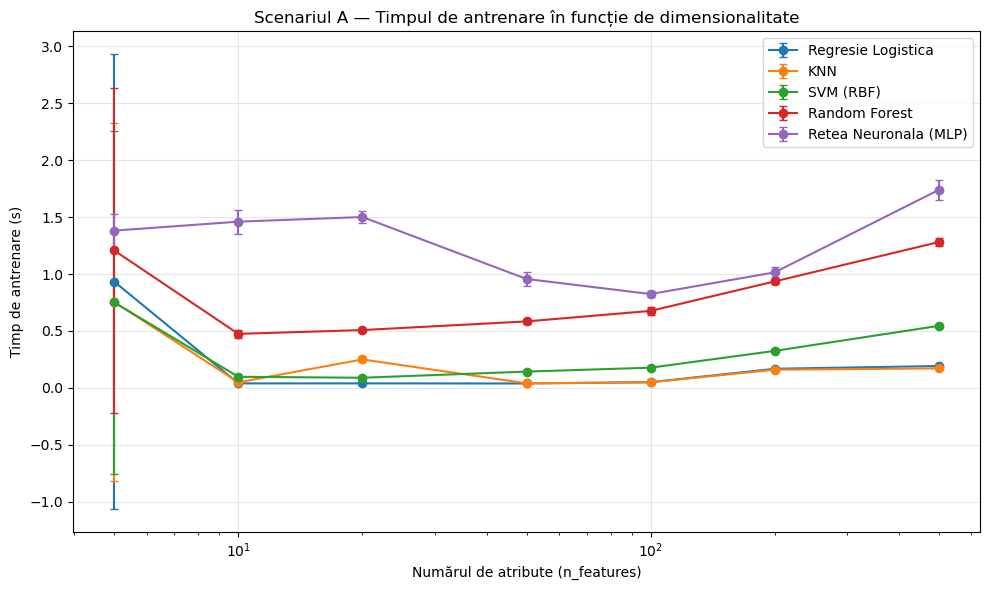

In [9]:
plot_scenario(df_A, "n_features", "train_time",
              title="Scenariul A — Timpul de antrenare în funcție de dimensionalitate",
              xlabel="Numărul de atribute (n_features)",
              ylabel="Timp de antrenare (s)",
              logx=True,
              savepath=RESULTS_DIR / "scenariu_A_train_time.png")


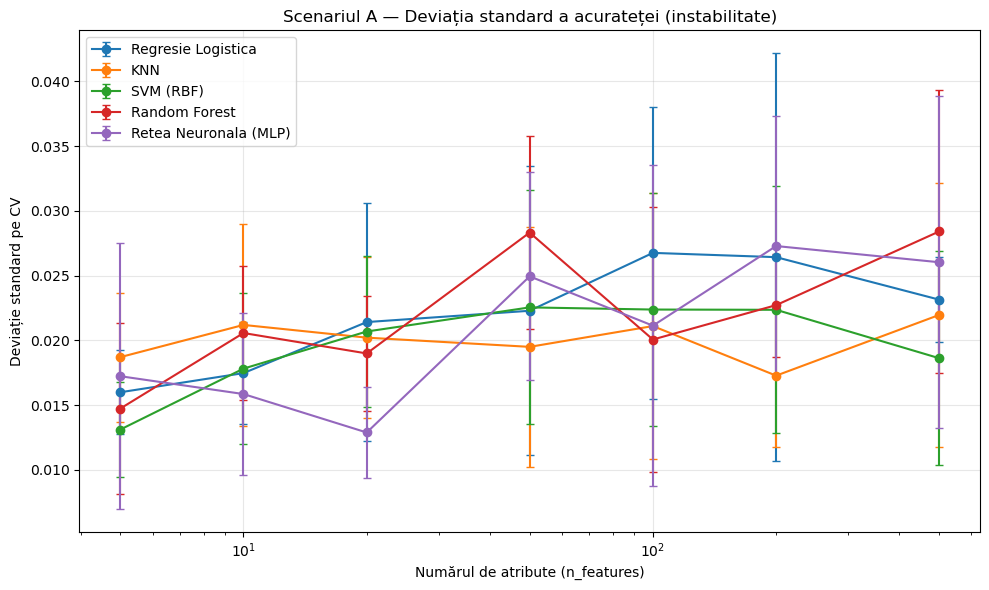

In [10]:
plot_scenario(df_A, "n_features", "accuracy_std",
              title="Scenariul A — Deviația standard a acurateței (instabilitate)",
              xlabel="Numărul de atribute (n_features)",
              ylabel="Deviație standard pe CV",
              logx=True,
              savepath=RESULTS_DIR / "scenariu_A_std.png")


## 6. Scenariul B — Impactul zgomotului în etichete

Se variază `flip_y ∈ [0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]`, păstrând:

- `n_features = 20`, `n_informative = 10`, `n_redundant = 0`
- `n_samples = 1000`

`flip_y` controlează proporția de etichete inversate aleator, deci simulează direct zgomotul în etichete (label noise).


In [11]:
FLIP_Y_LIST = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

def build_dataset_B(flip_y, seed):
    X, y = make_classification(
        n_samples=N_SAMPLES,
        n_features=20,
        n_informative=10,
        n_redundant=0,
        n_repeated=0,
        n_classes=2,
        flip_y=flip_y,
        class_sep=1.0,
        random_state=seed,
    )
    return X, y

print("Pornesc Scenariul B — zgomot...")
df_B = run_scenario("flip_y", FLIP_Y_LIST, build_dataset_B)
df_B.to_csv(RESULTS_DIR / "scenariu_B_zgomot.csv", index=False)
print("Salvat: scenariu_B_zgomot.csv")
df_B.head()


Pornesc Scenariul B — zgomot...
  [  1/35] flip_y=0.0, rep=0 — done
  [  2/35] flip_y=0.0, rep=1 — done
  [  3/35] flip_y=0.0, rep=2 — done
  [  4/35] flip_y=0.0, rep=3 — done
  [  5/35] flip_y=0.0, rep=4 — done
  [  6/35] flip_y=0.05, rep=0 — done
  [  7/35] flip_y=0.05, rep=1 — done
  [  8/35] flip_y=0.05, rep=2 — done
  [  9/35] flip_y=0.05, rep=3 — done
  [ 10/35] flip_y=0.05, rep=4 — done
  [ 11/35] flip_y=0.1, rep=0 — done
  [ 12/35] flip_y=0.1, rep=1 — done
  [ 13/35] flip_y=0.1, rep=2 — done
  [ 14/35] flip_y=0.1, rep=3 — done
  [ 15/35] flip_y=0.1, rep=4 — done
  [ 16/35] flip_y=0.15, rep=0 — done
  [ 17/35] flip_y=0.15, rep=1 — done
  [ 18/35] flip_y=0.15, rep=2 — done
  [ 19/35] flip_y=0.15, rep=3 — done
  [ 20/35] flip_y=0.15, rep=4 — done
  [ 21/35] flip_y=0.2, rep=0 — done
  [ 22/35] flip_y=0.2, rep=1 — done
  [ 23/35] flip_y=0.2, rep=2 — done
  [ 24/35] flip_y=0.2, rep=3 — done
  [ 25/35] flip_y=0.2, rep=4 — done
  [ 26/35] flip_y=0.25, rep=0 — done
  [ 27/35] flip_y=0.2

,flip_y,repetitie,model,accuracy_mean,accuracy_std,f1_mean,f1_std,auc_mean,auc_std,train_time
0,0.0,0,Regresie Logistica,0.828,0.026944,0.826697,0.029814,0.90730,0.020202,0.044319
1,0.0,0,KNN,0.879,0.013928,0.878578,0.013931,0.94524,0.010361,0.050114
2,0.0,0,SVM (RBF),0.904,0.019079,0.904566,0.020560,0.96344,0.012232,0.125369
3,0.0,0,Random Forest,0.891,0.023108,0.889634,0.025451,0.95483,0.012147,0.533742
4,0.0,0,Retea Neuronala (MLP),0.903,0.007483,0.904203,0.007637,0.96570,0.003339,1.799987


### 6.1. Sinteză — Scenariul B

In [12]:
summary_B = (
    df_B.groupby(["flip_y", "model"])
        .agg(accuracy_mean=("accuracy_mean", "mean"),
             accuracy_std=("accuracy_mean", "std"),
             f1_mean=("f1_mean", "mean"),
             auc_mean=("auc_mean", "mean"),
             train_time=("train_time", "mean"))
        .round(4)
        .reset_index()
)
summary_B.to_csv(RESULTS_DIR / "scenariu_B_sumar.csv", index=False)
summary_B


,flip_y,model,accuracy_mean,accuracy_std,f1_mean,auc_mean,train_time
0,0.00,KNN,0.8636,0.0318,0.8665,0.9314,0.0404
1,0.00,Random Forest,0.8884,0.0144,0.8892,0.9555,0.5061
2,0.00,Regresie Logistica,0.8282,0.0183,0.8290,0.9036,0.0406
3,0.00,Retea Neuronala (MLP),0.9152,0.0209,0.9160,0.9725,1.4606
4,0.00,SVM (RBF),0.9118,0.0254,0.9138,0.9672,0.1169
5,0.05,KNN,0.8450,0.0229,0.8471,0.9070,0.0400
6,0.05,Random Forest,0.8666,0.0141,0.8668,0.9292,0.4858
7,0.05,Regresie Logistica,0.8154,0.0230,0.8149,0.8815,0.0384
8,0.05,Retea Neuronala (MLP),0.8764,0.0327,0.8768,0.9349,1.6559
9,0.05,SVM (RBF),0.8858,0.0284,0.8879,0.9404,0.1246


### 6.2. Grafice — Scenariul B

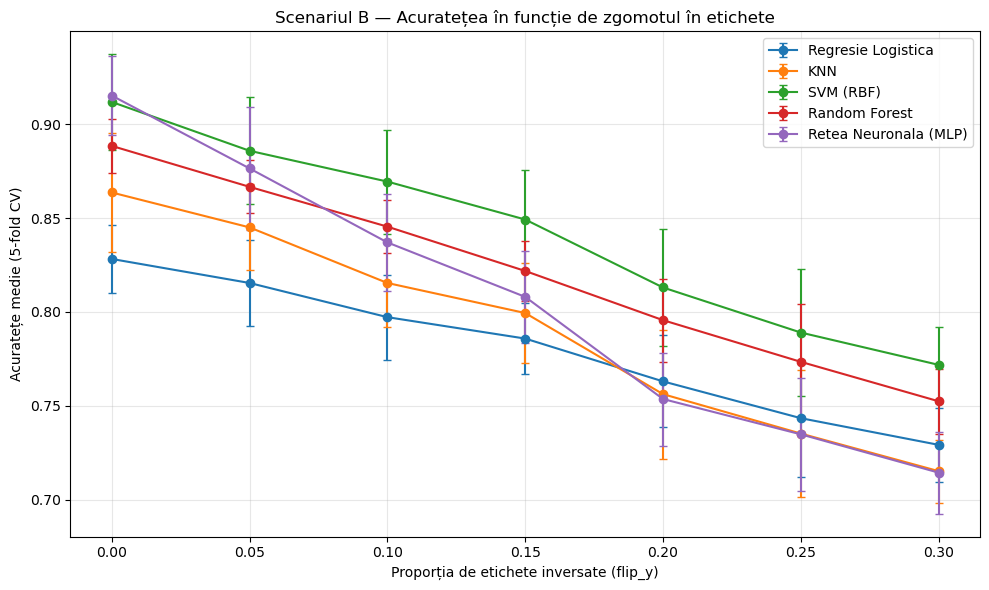

In [13]:
plot_scenario(df_B, "flip_y", "accuracy_mean",
              title="Scenariul B — Acuratețea în funcție de zgomotul în etichete",
              xlabel="Proporția de etichete inversate (flip_y)",
              ylabel="Acuratețe medie (5-fold CV)",
              savepath=RESULTS_DIR / "scenariu_B_accuracy.png")


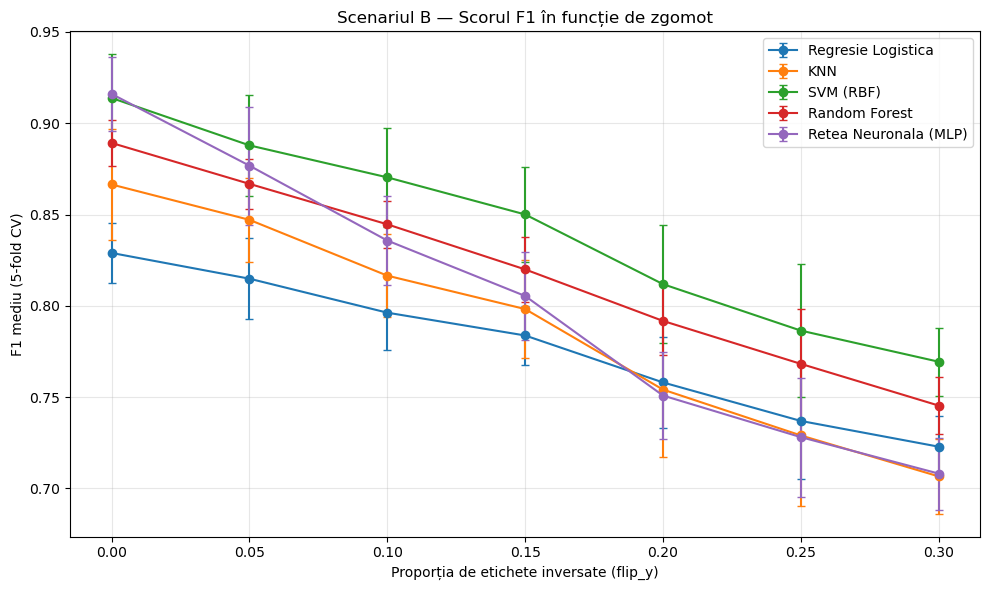

In [14]:
plot_scenario(df_B, "flip_y", "f1_mean",
              title="Scenariul B — Scorul F1 în funcție de zgomot",
              xlabel="Proporția de etichete inversate (flip_y)",
              ylabel="F1 mediu (5-fold CV)",
              savepath=RESULTS_DIR / "scenariu_B_f1.png")


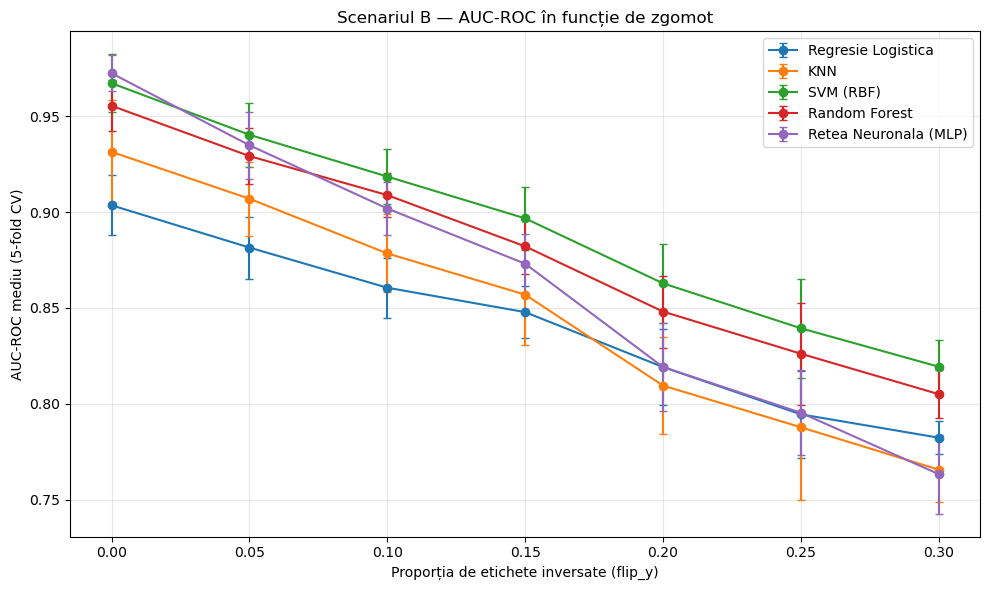

In [15]:
plot_scenario(df_B, "flip_y", "auc_mean",
              title="Scenariul B — AUC-ROC în funcție de zgomot",
              xlabel="Proporția de etichete inversate (flip_y)",
              ylabel="AUC-ROC mediu (5-fold CV)",
              savepath=RESULTS_DIR / "scenariu_B_auc.png")


## 7. Scenariul C — Impactul redundanței

Se variază proporția atributelor redundante. `n_features = 20` este fixat, iar `n_redundant` parcurge `[0, 2, 4, 6, 8, 10, 12]`. Pentru fiecare valoare, `n_informative = 20 - n_redundant`, astfel încât toate atributele sunt fie informative, fie redundante (combinații liniare ale celor informative).

Astfel, atunci când `n_redundant = 12`, aproximativ 60% din atribute sunt redundante, ceea ce simulează o multicoliniaritate severă.


In [16]:
N_REDUNDANT_LIST = [0, 2, 4, 6, 8, 10, 12]
TOTAL_FEATURES_C = 20

def build_dataset_C(n_redundant, seed):
    n_informative = TOTAL_FEATURES_C - n_redundant
    X, y = make_classification(
        n_samples=N_SAMPLES,
        n_features=TOTAL_FEATURES_C,
        n_informative=n_informative,
        n_redundant=n_redundant,
        n_repeated=0,
        n_classes=2,
        flip_y=0.01,
        class_sep=1.0,
        random_state=seed,
    )
    return X, y

print("Pornesc Scenariul C — redundanta...")
df_C = run_scenario("n_redundant", N_REDUNDANT_LIST, build_dataset_C)
df_C.to_csv(RESULTS_DIR / "scenariu_C_redundanta.csv", index=False)
print("Salvat: scenariu_C_redundanta.csv")
df_C.head()


Pornesc Scenariul C — redundanta...
  [  1/35] n_redundant=0, rep=0 — done
  [  2/35] n_redundant=0, rep=1 — done
  [  3/35] n_redundant=0, rep=2 — done
  [  4/35] n_redundant=0, rep=3 — done
  [  5/35] n_redundant=0, rep=4 — done
  [  6/35] n_redundant=2, rep=0 — done
  [  7/35] n_redundant=2, rep=1 — done
  [  8/35] n_redundant=2, rep=2 — done
  [  9/35] n_redundant=2, rep=3 — done
  [ 10/35] n_redundant=2, rep=4 — done
  [ 11/35] n_redundant=4, rep=0 — done
  [ 12/35] n_redundant=4, rep=1 — done
  [ 13/35] n_redundant=4, rep=2 — done
  [ 14/35] n_redundant=4, rep=3 — done
  [ 15/35] n_redundant=4, rep=4 — done
  [ 16/35] n_redundant=6, rep=0 — done
  [ 17/35] n_redundant=6, rep=1 — done
  [ 18/35] n_redundant=6, rep=2 — done
  [ 19/35] n_redundant=6, rep=3 — done
  [ 20/35] n_redundant=6, rep=4 — done
  [ 21/35] n_redundant=8, rep=0 — done
  [ 22/35] n_redundant=8, rep=1 — done
  [ 23/35] n_redundant=8, rep=2 — done
  [ 24/35] n_redundant=8, rep=3 — done
  [ 25/35] n_redundant=8, re

,n_redundant,repetitie,model,accuracy_mean,accuracy_std,f1_mean,f1_std,auc_mean,auc_std,train_time
0,0,0,Regresie Logistica,0.851,0.020347,0.849076,0.021388,0.928038,0.008629,0.040366
1,0,0,KNN,0.947,0.017776,0.946772,0.018243,0.983770,0.004777,0.037437
2,0,0,SVM (RBF),0.955,0.010954,0.955271,0.011427,0.986580,0.005093,0.112760
3,0,0,Random Forest,0.896,0.030561,0.896715,0.031977,0.956418,0.017646,0.489801
4,0,0,Retea Neuronala (MLP),0.955,0.007071,0.954998,0.007425,0.985000,0.005185,1.349019


### 7.1. Sinteză — Scenariul C

In [17]:
summary_C = (
    df_C.groupby(["n_redundant", "model"])
        .agg(accuracy_mean=("accuracy_mean", "mean"),
             accuracy_std=("accuracy_mean", "std"),
             f1_mean=("f1_mean", "mean"),
             auc_mean=("auc_mean", "mean"),
             train_time=("train_time", "mean"))
        .round(4)
        .reset_index()
)
summary_C.to_csv(RESULTS_DIR / "scenariu_C_sumar.csv", index=False)
summary_C


,n_redundant,model,accuracy_mean,accuracy_std,f1_mean,auc_mean,train_time
0,0,KNN,0.9376,0.0072,0.9372,0.9774,0.0373
1,0,Random Forest,0.8900,0.0070,0.8887,0.9511,0.4887
2,0,Regresie Logistica,0.8210,0.0265,0.8205,0.8972,0.0384
3,0,Retea Neuronala (MLP),0.9442,0.0101,0.9440,0.9841,1.2569
4,0,SVM (RBF),0.9488,0.0073,0.9485,0.9830,0.1094
5,2,KNN,0.9412,0.0091,0.9415,0.9780,0.0372
6,2,Random Forest,0.8942,0.0179,0.8933,0.9543,0.4907
7,2,Regresie Logistica,0.8186,0.0549,0.8184,0.8956,0.0386
8,2,Retea Neuronala (MLP),0.9450,0.0096,0.9451,0.9844,1.3660
9,2,SVM (RBF),0.9534,0.0093,0.9536,0.9852,0.1057


### 7.2. Grafice — Scenariul C

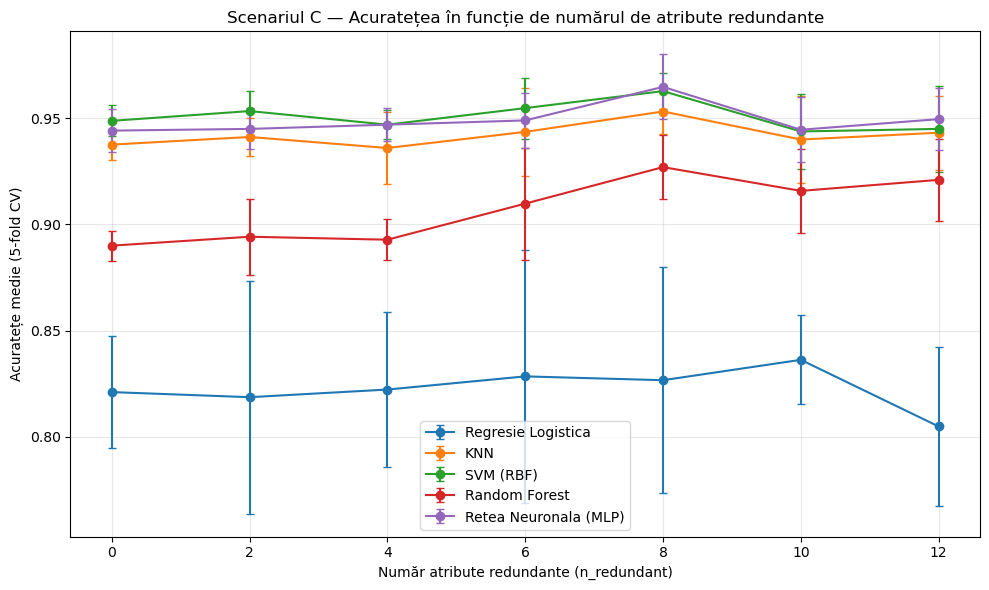

In [18]:
plot_scenario(df_C, "n_redundant", "accuracy_mean",
              title="Scenariul C — Acuratețea în funcție de numărul de atribute redundante",
              xlabel="Număr atribute redundante (n_redundant)",
              ylabel="Acuratețe medie (5-fold CV)",
              savepath=RESULTS_DIR / "scenariu_C_accuracy.png")


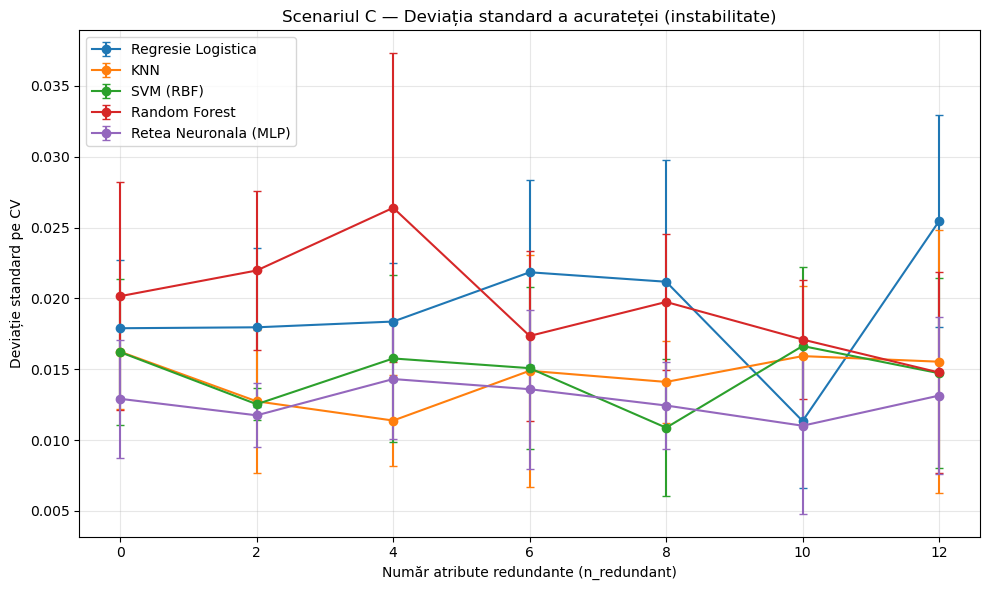

In [19]:
plot_scenario(df_C, "n_redundant", "accuracy_std",
              title="Scenariul C — Deviația standard a acurateței (instabilitate)",
              xlabel="Număr atribute redundante (n_redundant)",
              ylabel="Deviație standard pe CV",
              savepath=RESULTS_DIR / "scenariu_C_std.png")


## 8. Sinteză globală

Tabel comparativ cu performanța medie a fiecărui model pe cele trei scenarii, agregată pe toate valorile parametrului. Util pentru a obține o imagine de ansamblu și pentru a-l include direct în lucrare.


In [20]:
def overall_summary(df, scenario_label):
    out = (df.groupby("model")
             .agg(accuracy_mean=("accuracy_mean", "mean"),
                  accuracy_std=("accuracy_mean", "std"),
                  f1_mean=("f1_mean", "mean"),
                  auc_mean=("auc_mean", "mean"),
                  train_time_mean=("train_time", "mean"))
             .round(4)
             .reset_index())
    out.insert(0, "scenariu", scenario_label)
    return out

global_df = pd.concat([
    overall_summary(df_A, "A — Dimensionalitate"),
    overall_summary(df_B, "B — Zgomot"),
    overall_summary(df_C, "C — Redundanta"),
], ignore_index=True)

global_df.to_csv(RESULTS_DIR / "sumar_global.csv", index=False)
global_df


,scenariu,model,accuracy_mean,accuracy_std,f1_mean,auc_mean,train_time_mean
0,A — Dimensionalitate,KNN,0.8427,0.0445,0.8420,0.9066,0.2097
1,A — Dimensionalitate,Random Forest,0.8313,0.0897,0.8292,0.8983,0.8090
2,A — Dimensionalitate,Regresie Logistica,0.8076,0.0686,0.8078,0.8785,0.2079
3,A — Dimensionalitate,Retea Neuronala (MLP),0.8705,0.0614,0.8707,0.9328,1.2682
4,A — Dimensionalitate,SVM (RBF),0.8752,0.0502,0.8759,0.9386,0.3032
5,B — Zgomot,KNN,0.7900,0.0585,0.7883,0.8481,0.0390
6,B — Zgomot,Random Forest,0.8205,0.0499,0.8180,0.8793,0.5004
7,B — Zgomot,Regresie Logistica,0.7803,0.0403,0.7774,0.8413,0.0391
8,B — Zgomot,Retea Neuronala (MLP),0.8056,0.0746,0.8030,0.8657,1.6466
9,B — Zgomot,SVM (RBF),0.8414,0.0549,0.8414,0.8921,0.1290


### 8.1. Heatmap final — performanța comparativă

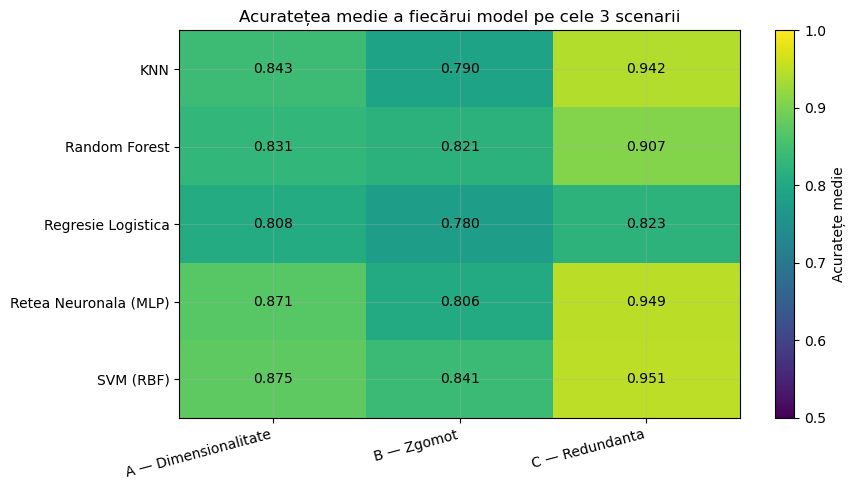

In [21]:
pivot = global_df.pivot(index="model", columns="scenariu", values="accuracy_mean")

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(pivot.values, cmap="viridis", aspect="auto", vmin=0.5, vmax=1.0)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=15, ha="right")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i, j]:.3f}",
                ha="center", va="center",
                color="white" if pivot.values[i, j] < 0.75 else "black")
plt.colorbar(im, ax=ax, label="Acuratețe medie")
ax.set_title("Acuratețea medie a fiecărui model pe cele 3 scenarii")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "heatmap_global.png", dpi=150, bbox_inches="tight")
plt.show()


## 9. Verificări finale 

In [22]:
# Verificare rapidă: listează fișierele salvate
for f in sorted(RESULTS_DIR.iterdir()):
    print(f.name, "—", f.stat().st_size, "bytes")


heatmap_global.png — 87973 bytes
scenariu_A_accuracy.png — 146577 bytes
scenariu_A_dimensionalitate.csv — 26306 bytes
scenariu_A_std.png — 140658 bytes
scenariu_A_sumar.csv — 1908 bytes
scenariu_A_train_time.png — 103239 bytes
scenariu_B_accuracy.png — 155108 bytes
scenariu_B_auc.png — 154267 bytes
scenariu_B_f1.png — 154898 bytes
scenariu_B_sumar.csv — 1947 bytes
scenariu_B_zgomot.csv — 26551 bytes
scenariu_C_accuracy.png — 106931 bytes
scenariu_C_redundanta.csv — 26270 bytes
scenariu_C_std.png — 141015 bytes
scenariu_C_sumar.csv — 1871 bytes
sumar_global.csv — 1078 bytes
